# Final Project by Denise Godinez (00001614313), Jack Mulvihill (00001623740), and Fareen Samad (00001663164)

## Abstract

## Imported Libraries

In [1]:
import glob

import numpy as np

import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import Perceptron
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score
from sklearn.metrics import ConfusionMatrixDisplay

## Data Extraction

In [2]:
# Preview one of the data sources
ex = pd.read_json('ids_4.json', lines=True)

# Display the columns
print(ex.columns)

display(ex.head())

Index([' Destination Port', ' Flow Duration', ' Total Fwd Packets',
       ' Total Backward Packets', 'Total Length of Fwd Packets',
       ' Total Length of Bwd Packets', ' Fwd Packet Length Max',
       ' Fwd Packet Length Min', ' Fwd Packet Length Mean',
       ' Fwd Packet Length Std', 'Bwd Packet Length Max',
       ' Bwd Packet Length Min', ' Bwd Packet Length Mean',
       ' Bwd Packet Length Std', 'Flow Bytes/s', ' Flow Packets/s',
       ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max', ' Flow IAT Min',
       'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std', ' Fwd IAT Max',
       ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean', ' Bwd IAT Std',
       ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags', ' Bwd PSH Flags',
       ' Fwd URG Flags', ' Bwd URG Flags', ' Fwd Header Length',
       ' Bwd Header Length', 'Fwd Packets/s', ' Bwd Packets/s',
       ' Min Packet Length', ' Max Packet Length', ' Packet Length Mean',
       ' Packet Length Std', ' Packet Length Variance', '

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,80,27887,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,53,181,2,2,74,154,37,37,37.0,0.0,...,44,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,80,115,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,80,13,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,56529,50,1,1,0,0,0,0,0.0,0.0,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [3]:
"""This functions combines all the csv, json, and parquet files into a dataframe

    Args:
        None: The function reads all csv, json, and parquet files in the working directory
        
    Returns:
        data (pd.DataFrame): All data sources combined in a single dataframe
    """
def extract() -> pd.DataFrame:
    
    # Create a new dataframe to hold all the data
    # Column names chosen based on what was returned from .columns
    data = pd.DataFrame(columns=[' Destination Port', ' Flow Duration', ' Total Fwd Packets',
                                 ' Total Backward Packets', 'Total Length of Fwd Packets',
                                 ' Total Length of Bwd Packets', ' Fwd Packet Length Max',
                                 ' Fwd Packet Length Min', ' Fwd Packet Length Mean',
                                 ' Fwd Packet Length Std', 'Bwd Packet Length Max',
                                 ' Bwd Packet Length Min', ' Bwd Packet Length Mean',
                                 ' Bwd Packet Length Std', 'Flow Bytes/s', ' Flow Packets/s',
                                 ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max', ' Flow IAT Min',
                                 'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std', ' Fwd IAT Max',
                                 ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean', ' Bwd IAT Std',
                                 ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags', ' Bwd PSH Flags',
                                 ' Fwd URG Flags', ' Bwd URG Flags', ' Fwd Header Length',
                                 ' Bwd Header Length', 'Fwd Packets/s', ' Bwd Packets/s',
                                 ' Min Packet Length', ' Max Packet Length', ' Packet Length Mean',
                                 ' Packet Length Std', ' Packet Length Variance', 'FIN Flag Count',
                                 ' SYN Flag Count', ' RST Flag Count', ' PSH Flag Count',
                                 ' ACK Flag Count', ' URG Flag Count', ' CWE Flag Count',
                                 ' ECE Flag Count', ' Down/Up Ratio', ' Average Packet Size',
                                 ' Avg Fwd Segment Size', ' Avg Bwd Segment Size',
                                 ' Fwd Header Length.1', 'Fwd Avg Bytes/Bulk', ' Fwd Avg Packets/Bulk',
                                 ' Fwd Avg Bulk Rate', ' Bwd Avg Bytes/Bulk', ' Bwd Avg Packets/Bulk',
                                 'Bwd Avg Bulk Rate', 'Subflow Fwd Packets', ' Subflow Fwd Bytes',
                                 ' Subflow Bwd Packets', ' Subflow Bwd Bytes', 'Init_Win_bytes_forward',
                                 ' Init_Win_bytes_backward', ' act_data_pkt_fwd',
                                 ' min_seg_size_forward', 'Active Mean', ' Active Std', ' Active Max',
                                 ' Active Min', 'Idle Mean', ' Idle Std', ' Idle Max', ' Idle Min',' Label'])
    
    # Load the csv files
    for csvfile in glob.glob('*.csv'):
        
        # Load current csv into the temp dataframe
        temp = pd.read_csv(csvfile)
        
        # Combine the loaded csv files into data
        data = pd.concat([data, temp], ignore_index=True)
    
    # Load the json files
    for jsonfile in glob.glob('*.json'):
        
        # Load current json into the temp dataframe
        temp = pd.read_json(jsonfile, lines=True)
        
        # Combine the loaded json files into data
        data = pd.concat([data, temp], ignore_index=True)
    
    # Load the parquet files
    for parquetfile in glob.glob('*.parquet'):
        
        # Load the current parquet file into the temp dataframe
        temp = pd.read_parquet(parquetfile)
        
        # Combine the loaded parquet files into data
        data = pd.concat([data, temp], ignore_index=True)

    # Standardize all column names to lowercase with underscores before deduplicating
    data.columns = data.columns.str.strip().str.lower().str.replace(' ', '_').str.replace('/', '_')
    
    # Keep only the first occurrence of each duplicate column name
    data = data.loc[:, ~data.columns.duplicated()]

    # Drop all rows that are entirely NaN
    data = data.dropna(how='all')

    # drop rows with no label
    data = data.dropna(subset=['label']) 

    # Return the newly extracted data
    return data

Because all of these data sources share the same attributes, the best approach is to combine all the data from all the files into one combined DataFrame for easy analysis.

In [4]:
# Extract the data into a dataframe data
data = extract()

# Display all columns
pd.set_option('display.max_columns', None)
display(data.head())

,destination_port,flow_duration,total_fwd_packets,total_backward_packets,total_length_of_fwd_packets,total_length_of_bwd_packets,fwd_packet_length_max,fwd_packet_length_min,fwd_packet_length_mean,fwd_packet_length_std,bwd_packet_length_max,bwd_packet_length_min,bwd_packet_length_mean,bwd_packet_length_std,flow_bytes_s,flow_packets_s,flow_iat_mean,flow_iat_std,flow_iat_max,flow_iat_min,fwd_iat_total,fwd_iat_mean,fwd_iat_std,fwd_iat_max,fwd_iat_min,bwd_iat_total,bwd_iat_mean,bwd_iat_std,bwd_iat_max,bwd_iat_min,fwd_psh_flags,bwd_psh_flags,fwd_urg_flags,bwd_urg_flags,fwd_header_length,bwd_header_length,fwd_packets_s,bwd_packets_s,min_packet_length,max_packet_length,packet_length_mean,packet_length_std,packet_length_variance,fin_flag_count,syn_flag_count,rst_flag_count,psh_flag_count,ack_flag_count,urg_flag_count,cwe_flag_count,ece_flag_count,down_up_ratio,average_packet_size,avg_fwd_segment_size,avg_bwd_segment_size,fwd_header_length.1,fwd_avg_bytes_bulk,fwd_avg_packets_bulk,fwd_avg_bulk_rate,bwd_avg_bytes_bulk,bwd_avg_packets_bulk,bwd_avg_bulk_rate,subflow_fwd_packets,subflow_fwd_bytes,subflow_bwd_packets,subflow_bwd_bytes,init_win_bytes_forward,init_win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,active_mean,active_std,active_max,active_min,idle_mean,idle_std,idle_max,idle_min,label,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66
110382,55109,17,1,1,6,6,6,6,6.0,0.0,6,6,6.0,0.0,705882.3529,117647.0588,17.0,0.0,17,17,0,0.0,0.0,0,0,0,0.0,0.0,0,0,0,0,0,0,20,20,58823.52941,58823.52941,6,6,6.0,0.0,0.0,0,0,0,0,1,1,0,0,1,9.0,6.0,6.0,20,0,0,0,0,0,0,1,6,1,6,1013,16213,0,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
110383,53,113594958,4,4,152,362,45,31,38.0,8.082904,120,61,90.5,34.063666,4.524849,0.070426,16200000.0,42900000.0,114000000,3,114000000,37900000.0,65600000.0,114000000,3,114000000,37900000.0,65600000.0,114000000,48,0,0,0,0,128,128,0.035213,0.035213,31,120,60.555556,35.658488,1271.527778,0,0,0,0,0,0,0,0,1,68.125,38.0,90.5,128,0,0,0,0,0,0,4,152,4,362,-1,-1,3,32,240.0,0.0,240,240,114000000.0,0.0,114000000,114000000,BENIGN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
110384,53,30485,1,1,81,209,81,81,81.0,0.0,209,209,209.0,0.0,9512.875185,65.606036,30485.0,0.0,30485,30485,0,0.0,0.0,0,0,0,0.0,0.0,0,0,0,0,0,0,32,32,32.803018,32.803018,81,209,123.666667,73.900834,5461.333333,0,0,0,0,0,0,0,0,1,185.5,81.0,209.0,32,0,0,0,0,0,0,1,81,1,209,-1,-1,0,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
110385,53,30445,1,1,53,81,53,53,53.0,0.0,81,81,81.0,0.0,4401.379537,65.692232,30445.0,0.0,30445,30445,0,0.0,0.0,0,0,0,0.0,0.0,0,0,0,0,0,0,32,20,32.846116,32.846116,53,81,62.333333,16.165808,261.333333,0,0,0,0,0,0,0,0,1,93.5,53.0,81.0,32,0,0,0,0,0,0,1,53,1,81,-1,-1,0,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
110386,53,70860,1,1,56,72,56,56,56.0,0.0,72,72,72.0,0.0,1806.378775,28.224668,70860.0,0.0,70860,70860,0,0.0,0.0,0,0,0,0.0,

## Data Transformation

In [5]:
# Display the data types of each attribute in the newly created combined DataFrame
print(data.dtypes)

destination_port                object
flow_duration                   object
total_fwd_packets               object
total_backward_packets          object
total_length_of_fwd_packets     object
                                ...   
62                             float64
63                             float64
64                             float64
65                             float64
66                             float64
Length: 146, dtype: object


All of these data types seem to be object. So, convert them as necessary based on the information provided when displaying data.

In [6]:
def transform(data: pd.DataFrame) -> pd.DataFrame:
    
    # Drop any remaining duplicate columns
    data = data.loc[:, ~data.columns.duplicated()]
    
    # Drop rows where label is missing
    data = data.dropna(subset=['label'])
    
    # Convert all non-label columns to numeric, coercing errors to NaN
    for col in data.columns:
        if col != 'label':
            data[col] = pd.to_numeric(data[col], errors='coerce')
    

   # Drop columns that are entirely NaN
    data = data.dropna(axis=1, how='all')

    # Drop the .1 duplicate columns that slipped through, but keep label
    data = data[[c for c in data.columns if not c.endswith('.1') or c == 'label']]

    # Drop rows where label is missing
    data = data.dropna(subset=['label'])
    
    # Ensure label is a string
    data['label'] = data['label'].astype('string')

    # Drop the small number of remaining NaN rows
    data = data.dropna()
    
    return data

In [7]:
# Transform the data and display the first few rows to verify the changes
data = transform(data)
display(data.head())

,destination_port,flow_duration,total_fwd_packets,total_backward_packets,total_length_of_fwd_packets,total_length_of_bwd_packets,fwd_packet_length_max,fwd_packet_length_min,fwd_packet_length_mean,fwd_packet_length_std,bwd_packet_length_max,bwd_packet_length_min,bwd_packet_length_mean,bwd_packet_length_std,flow_bytes_s,flow_packets_s,flow_iat_mean,flow_iat_std,flow_iat_max,flow_iat_min,fwd_iat_total,fwd_iat_mean,fwd_iat_std,fwd_iat_max,fwd_iat_min,bwd_iat_total,bwd_iat_mean,bwd_iat_std,bwd_iat_max,bwd_iat_min,fwd_psh_flags,bwd_psh_flags,fwd_urg_flags,bwd_urg_flags,fwd_header_length,bwd_header_length,fwd_packets_s,bwd_packets_s,min_packet_length,max_packet_length,packet_length_mean,packet_length_std,packet_length_variance,fin_flag_count,syn_flag_count,rst_flag_count,psh_flag_count,ack_flag_count,urg_flag_count,cwe_flag_count,ece_flag_count,down_up_ratio,average_packet_size,avg_fwd_segment_size,avg_bwd_segment_size,fwd_avg_bytes_bulk,fwd_avg_packets_bulk,fwd_avg_bulk_rate,bwd_avg_bytes_bulk,bwd_avg_packets_bulk,bwd_avg_bulk_rate,subflow_fwd_packets,subflow_fwd_bytes,subflow_bwd_packets,subflow_bwd_bytes,init_win_bytes_forward,init_win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,active_mean,active_std,active_max,active_min,idle_mean,idle_std,idle_max,idle_min,label
110382,55109,17,1,1,6,6,6,6,6.0,0.000000,6,6,6.0,0.000000,705882.352900,117647.058800,17.0,0.0,17,17,0,0.0,0.0,0,0,0,0.0,0.0,0,0,0,0,0,0,20,20,58823.529410,58823.529410,6,6,6.000000,0.000000,0.000000,0,0,0,0,1,1,0,0,1,9.000,6.0,6.0,0,0,0,0,0,0,1,6,1,6,1013,16213,0,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
110383,53,113594958,4,4,152,362,45,31,38.0,8.082904,120,61,90.5,34.063666,4.524849,0.070426,16200000.0,42900000.0,114000000,3,114000000,37900000.0,65600000.0,114000000,3,114000000,37900000.0,65600000.0,114000000,48,0,0,0,0,128,128,0.035213,0.035213,31,120,60.555556,35.658488,1271.527778,0,0,0,0,0,0,0,0,1,68.125,38.0,90.5,0,0,0,0,0,0,4,152,4,362,-1,-1,3,32,240.0,0.0,240,240,114000000.0,0.0,114000000,114000000,BENIGN
110384,53,30485,1,1,81,209,81,81,81.0,0.000000,209,209,209.0,0.000000,9512.875185,65.606036,30485.0,0.0,30485,30485,0,0.0,0.0,0,0,0,0.0,0.0,0,0,0,0,0,0,32,32,32.803018,32.803018,81,209,123.666667,73.900834,5461.333333,0,0,0,0,0,0,0,0,1,185.500,81.0,209.0,0,0,0,0,0,0,1,81,1,209,-1,-1,0,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
110385,53,30445,1,1,53,81,53,53,53.0,0.000000,81,81,81.0,0.000000,4401.379537,65.692232,30445.0,0.0,30445,30445,0,0.0,0.0,0,0,0,0.0,0.0,0,0,0,0,0,0,32,20,32.846116,32.846116,53,81,62.333333,16.165808,261.333333,0,0,0,0,0,0,0,0,1,93.500,53.0,81.0,0,0,0,0,0,0,1,53,1,81,-1,-1,0,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
110386,53,70860,1,1,56,72,56,56,56.0,0.000000,72,72,72.0,0.000000,1806.378775,28.224668,70860.0,0.0,70860,70860,0,0.0,0.0,0,0,0,0.0,0.0,0,0,0,0,0,0,32,32,14.112334,14.112334,56,72,61.333333,9.237604,85.333333,0,0,0,0,0,0,0,0,1,92.000,56.0,72.0,0,0,0,0,0,0,1,56,1,72,-1,-1,0,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [8]:
# Check the shape of the data and look for any remaining duplicate columns
print(data.shape)
print([c for c in data.columns if data.columns.tolist().count(c) > 1])

(63011, 78)
[]


The naming of the columns was inconsistent and contained a lot of unnecessary whitespace, which made it confusing for the users. So, the main goal of transformation was to convert all of the feature names into a standardized format to make working with them easier down the line. In doing so, a duplicate column was identified and deleted from the dataset. The other major issue that needed to be addressed was that all of the data types were of type "object." Based on what was provided when previewing the data, converted all of the data types as appropriate. This included changing the counts and numbers to integers, statistical data to floats, and labels to strings.  

## Data Loading and Storage

In [9]:
"""This function loads the argument dataframe data into the csv file identified by filename

    Args:
        data (pd.DataFrame): transformed dataframe
        filename (str): the csv
    """
def loadcsv(data: pd.DataFrame, filename: str) -> None:
    
    # Use .to_csv to convert the dataframe into a CSV
    # use an f-string to write the filename as the string parameter, do not index
    data.to_csv(f'{filename}', index=False)

In [10]:
# Create the CSV file with the transformed data
loadcsv(data, 'transformed_data.csv')

Loading the transformed data into a CSV file seems like the most logical choice here given that no use of SQL will be necessary in the foreseeable future.

## Data Reading

In [11]:
# Load the transformed data into a new dataframe to confirm the transformations were successful
cleaned_data = pd.read_csv('transformed_data.csv')

# Display all columns
pd.set_option('display.max_columns', None)
display(cleaned_data.head())

,destination_port,flow_duration,total_fwd_packets,total_backward_packets,total_length_of_fwd_packets,total_length_of_bwd_packets,fwd_packet_length_max,fwd_packet_length_min,fwd_packet_length_mean,fwd_packet_length_std,bwd_packet_length_max,bwd_packet_length_min,bwd_packet_length_mean,bwd_packet_length_std,flow_bytes_s,flow_packets_s,flow_iat_mean,flow_iat_std,flow_iat_max,flow_iat_min,fwd_iat_total,fwd_iat_mean,fwd_iat_std,fwd_iat_max,fwd_iat_min,bwd_iat_total,bwd_iat_mean,bwd_iat_std,bwd_iat_max,bwd_iat_min,fwd_psh_flags,bwd_psh_flags,fwd_urg_flags,bwd_urg_flags,fwd_header_length,bwd_header_length,fwd_packets_s,bwd_packets_s,min_packet_length,max_packet_length,packet_length_mean,packet_length_std,packet_length_variance,fin_flag_count,syn_flag_count,rst_flag_count,psh_flag_count,ack_flag_count,urg_flag_count,cwe_flag_count,ece_flag_count,down_up_ratio,average_packet_size,avg_fwd_segment_size,avg_bwd_segment_size,fwd_avg_bytes_bulk,fwd_avg_packets_bulk,fwd_avg_bulk_rate,bwd_avg_bytes_bulk,bwd_avg_packets_bulk,bwd_avg_bulk_rate,subflow_fwd_packets,subflow_fwd_bytes,subflow_bwd_packets,subflow_bwd_bytes,init_win_bytes_forward,init_win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,active_mean,active_std,active_max,active_min,idle_mean,idle_std,idle_max,idle_min,label
0,55109,17,1,1,6,6,6,6,6.0,0.000000,6,6,6.0,0.000000,705882.352900,117647.058800,17.0,0.0,17,17,0,0.0,0.0,0,0,0,0.0,0.0,0,0,0,0,0,0,20,20,58823.529410,58823.529410,6,6,6.000000,0.000000,0.000000,0,0,0,0,1,1,0,0,1,9.000,6.0,6.0,0,0,0,0,0,0,1,6,1,6,1013,16213,0,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,53,113594958,4,4,152,362,45,31,38.0,8.082904,120,61,90.5,34.063666,4.524849,0.070426,16200000.0,42900000.0,114000000,3,114000000,37900000.0,65600000.0,114000000,3,114000000,37900000.0,65600000.0,114000000,48,0,0,0,0,128,128,0.035213,0.035213,31,120,60.555556,35.658488,1271.527778,0,0,0,0,0,0,0,0,1,68.125,38.0,90.5,0,0,0,0,0,0,4,152,4,362,-1,-1,3,32,240.0,0.0,240,240,114000000.0,0.0,114000000,114000000,BENIGN
2,53,30485,1,1,81,209,81,81,81.0,0.000000,209,209,209.0,0.000000,9512.875185,65.606036,30485.0,0.0,30485,30485,0,0.0,0.0,0,0,0,0.0,0.0,0,0,0,0,0,0,32,32,32.803018,32.803018,81,209,123.666667,73.900834,5461.333333,0,0,0,0,0,0,0,0,1,185.500,81.0,209.0,0,0,0,0,0,0,1,81,1,209,-1,-1,0,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,53,30445,1,1,53,81,53,53,53.0,0.000000,81,81,81.0,0.000000,4401.379537,65.692232,30445.0,0.0,30445,30445,0,0.0,0.0,0,0,0,0.0,0.0,0,0,0,0,0,0,32,20,32.846116,32.846116,53,81,62.333333,16.165808,261.333333,0,0,0,0,0,0,0,0,1,93.500,53.0,81.0,0,0,0,0,0,0,1,53,1,81,-1,-1,0,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,53,70860,1,1,56,72,56,56,56.0,0.000000,72,72,72.0,0.000000,1806.378775,28.224668,70860.0,0.0,70860,70860,0,0.0,0.0,0,0,0,0.0,0.0,0,0,0,0,0,0,32,32,14.112334,14.112334,56,72,61.333333,9.237604,85.333333,0,0,0,0,0,0,0,0,1,92.000,56.0,72.0,0,0,0,0,0,0,1,56,1,72,-1,-1,0,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


Data cleaning steps were successful, load into a new DataFrame.

## Data Analysis

In [12]:
# Display the dimensions of the newly transformed data
cleaned_data.shape

(63011, 78)

In [13]:
# Identify unique values in the label column and their counts
unique_labels = cleaned_data['label'].value_counts()
print(unique_labels)

label
DoS Hulk            30909
DoS GoldenEye       20586
BENIGN               6006
DoS Slowhttptest     5499
Heartbleed             11
Name: count, dtype: int64


In [14]:
# Identify if the dataset has missing data
cleaned_data.isna().sum()

destination_port               0
flow_duration                  0
total_fwd_packets              0
total_backward_packets         0
total_length_of_fwd_packets    0
                              ..
idle_mean                      0
idle_std                       0
idle_max                       0
idle_min                       0
label                          0
Length: 78, dtype: int64

There does not seem to be any missing data.

In [15]:
# Display the summary statistics of the transformed data
cleaned_data.describe()

/opt/miniconda3/envs/comp379/lib/python3.11/site-packages/pandas/core/nanops.py:1020: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
/opt/miniconda3/envs/comp379/lib/python3.11/site-packages/pandas/core/nanops.py:1020: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,destination_port,flow_duration,total_fwd_packets,total_backward_packets,total_length_of_fwd_packets,total_length_of_bwd_packets,fwd_packet_length_max,fwd_packet_length_min,fwd_packet_length_mean,fwd_packet_length_std,bwd_packet_length_max,bwd_packet_length_min,bwd_packet_length_mean,bwd_packet_length_std,flow_bytes_s,flow_packets_s,flow_iat_mean,flow_iat_std,flow_iat_max,flow_iat_min,fwd_iat_total,fwd_iat_mean,fwd_iat_std,fwd_iat_max,fwd_iat_min,bwd_iat_total,bwd_iat_mean,bwd_iat_std,bwd_iat_max,bwd_iat_min,fwd_psh_flags,bwd_psh_flags,fwd_urg_flags,bwd_urg_flags,fwd_header_length,bwd_header_length,fwd_packets_s,bwd_packets_s,min_packet_length,max_packet_length,packet_length_mean,packet_length_std,packet_length_variance,fin_flag_count,syn_flag_count,rst_flag_count,psh_flag_count,ack_flag_count,urg_flag_count,cwe_flag_count,ece_flag_count,down_up_ratio,average_packet_size,avg_fwd_segment_size,avg_bwd_segment_size,fwd_avg_bytes_bulk,fwd_avg_packets_bulk,fwd_avg_bulk_rate,bwd_avg_bytes_bulk,bwd_avg_packets_bulk,bwd_avg_bulk_rate,subflow_fwd_packets,subflow_fwd_bytes,subflow_bwd_packets,subflow_bwd_bytes,init_win_bytes_forward,init_win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,active_mean,active_std,active_max,active_min,idle_mean,idle_std,idle_max,idle_min
count,63011.000000,6.301100e+04,63011.000000,63011.000000,63011.000000,6.301100e+04,63011.000000,63011.000000,63011.000000,63011.000000,63011.000000,63011.000000,63011.000000,63011.000000,6.301100e+04,6.301100e+04,6.301100e+04,6.301100e+04,6.301100e+04,6.301100e+04,6.301100e+04,6.301100e+04,6.301100e+04,6.301100e+04,6.301100e+04,6.301100e+04,6.301100e+04,6.301100e+04,6.301100e+04,6.301100e+04,63011.000000,63011.0,63011.0,63011.0,63011.000000,63011.000000,6.301100e+04,6.301100e+04,63011.00000,63011.000000,63011.000000,63011.000000,6.301100e+04,63011.000000,63011.000000,63011.000000,63011.000000,63011.000000,63011.000000,63011.0,63011.000000,63011.000000,63011.000000,63011.000000,63011.000000,63011.0,63011.0,63011.0,63011.0,63011.0,63011.0,63011.000000,63011.000000,63011.000000,6.301100e+04,63011.000000,63011.000000,63011.000000,63011.000000,6.301100e+04,6.301100e+04,6.301100e+04,6.301100e+04,6.301100e+04,6.301100e+04,6.301100e+04,6.301100e+04
mean,997.173652,4.191835e+07,6.860723,5.373522,403.856581,1.012085e+04,261.973687,12.307851,61.730789,102.013618,3400.032661,5.023393,1062.894419,1464.132131,inf,inf,7.794233e+06,1.086658e+07,3.822734e+07,3.794344e+06,4.070702e+07,1.138005e+07,1.382967e+07,3.805226e+07,5.134200e+06,1.486574e+07,3.452290e+06,5.944157e+06,1.302840e+07,2.535379e+05,0.019885,0.0,0.0,0.0,210.730253,160.682928,9.483906e+04,1.884892e+03,3.65360,3434.315389,478.687564,1043.810363,2.011086e+06,0.128073,0.019885,0.000016,0.355493,0.475282,0.023583,0.0,0.000016,0.293742,521.564154,61.730789,1062.894419,0.0,0.0,0.0,0.0,0.0,0.0,6.860723,403.856581,5.373522,1.012011e+04,10436.992224,527.256574,2.172335,29.574646,4.168974e+05,3.254984e+04,4.452388e+05,3.918061e+05,3.675259e+07,1.032670e+06,3.775372e+07,3.592037e+07
std,6715.175550,4.278971e+07,112.515356,147.232105,2321.468445,3.386248e+05,323.441328,124.958706,143.810130,120.874005,3311.689269,28.186808,973.596595,1463.262768,NaN,NaN,1.612811e+07,1.418842e+07,4.248592e+07,1.567987e+07,4.363299e+07,1.925922e+07,1.829230e+07,4.262989e+07,1.905557e+07,3.145518e+07,8.870447e+06,1.451933e+07,3.031892e+07,3.433833e+06,0.139608,0.0,0.0,0.0,2442.402712,3019.660865,3.303006e+05,2.669360e+04,25.49121,3287.474365,414.760208,959.920313,2.412462e+06,0.334174,0.139608,0.003984,0.478666,0.499393,0.151748,0.0,0.003984,0.525015,452.802671,143.810130,973.596595,0.0,0.0,0.0,0.0,0.0,0.0,112.515356,2321.468445,147.232105,3.385413e+05,13942.090597,3693.489561,104.764763,5.554531,1.563773e+06,4.115889e+05,1.656852e+06,1.533074e+06,4.274796e+07,5.572811e+06,4.284834e+07,4.303636e+07
min,0.000000,0.000000e+00,1.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,1.

Because there are so many features, including duplicates, generating visuals such as pair plots would be unwieldly and difficult to read. 

## Data Preprocessing

In [16]:
# Display the cleaned data to confirm the transformations were successful
display(cleaned_data.head())

,destination_port,flow_duration,total_fwd_packets,total_backward_packets,total_length_of_fwd_packets,total_length_of_bwd_packets,fwd_packet_length_max,fwd_packet_length_min,fwd_packet_length_mean,fwd_packet_length_std,bwd_packet_length_max,bwd_packet_length_min,bwd_packet_length_mean,bwd_packet_length_std,flow_bytes_s,flow_packets_s,flow_iat_mean,flow_iat_std,flow_iat_max,flow_iat_min,fwd_iat_total,fwd_iat_mean,fwd_iat_std,fwd_iat_max,fwd_iat_min,bwd_iat_total,bwd_iat_mean,bwd_iat_std,bwd_iat_max,bwd_iat_min,fwd_psh_flags,bwd_psh_flags,fwd_urg_flags,bwd_urg_flags,fwd_header_length,bwd_header_length,fwd_packets_s,bwd_packets_s,min_packet_length,max_packet_length,packet_length_mean,packet_length_std,packet_length_variance,fin_flag_count,syn_flag_count,rst_flag_count,psh_flag_count,ack_flag_count,urg_flag_count,cwe_flag_count,ece_flag_count,down_up_ratio,average_packet_size,avg_fwd_segment_size,avg_bwd_segment_size,fwd_avg_bytes_bulk,fwd_avg_packets_bulk,fwd_avg_bulk_rate,bwd_avg_bytes_bulk,bwd_avg_packets_bulk,bwd_avg_bulk_rate,subflow_fwd_packets,subflow_fwd_bytes,subflow_bwd_packets,subflow_bwd_bytes,init_win_bytes_forward,init_win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,active_mean,active_std,active_max,active_min,idle_mean,idle_std,idle_max,idle_min,label
0,55109,17,1,1,6,6,6,6,6.0,0.000000,6,6,6.0,0.000000,705882.352900,117647.058800,17.0,0.0,17,17,0,0.0,0.0,0,0,0,0.0,0.0,0,0,0,0,0,0,20,20,58823.529410,58823.529410,6,6,6.000000,0.000000,0.000000,0,0,0,0,1,1,0,0,1,9.000,6.0,6.0,0,0,0,0,0,0,1,6,1,6,1013,16213,0,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,53,113594958,4,4,152,362,45,31,38.0,8.082904,120,61,90.5,34.063666,4.524849,0.070426,16200000.0,42900000.0,114000000,3,114000000,37900000.0,65600000.0,114000000,3,114000000,37900000.0,65600000.0,114000000,48,0,0,0,0,128,128,0.035213,0.035213,31,120,60.555556,35.658488,1271.527778,0,0,0,0,0,0,0,0,1,68.125,38.0,90.5,0,0,0,0,0,0,4,152,4,362,-1,-1,3,32,240.0,0.0,240,240,114000000.0,0.0,114000000,114000000,BENIGN
2,53,30485,1,1,81,209,81,81,81.0,0.000000,209,209,209.0,0.000000,9512.875185,65.606036,30485.0,0.0,30485,30485,0,0.0,0.0,0,0,0,0.0,0.0,0,0,0,0,0,0,32,32,32.803018,32.803018,81,209,123.666667,73.900834,5461.333333,0,0,0,0,0,0,0,0,1,185.500,81.0,209.0,0,0,0,0,0,0,1,81,1,209,-1,-1,0,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,53,30445,1,1,53,81,53,53,53.0,0.000000,81,81,81.0,0.000000,4401.379537,65.692232,30445.0,0.0,30445,30445,0,0.0,0.0,0,0,0,0.0,0.0,0,0,0,0,0,0,32,20,32.846116,32.846116,53,81,62.333333,16.165808,261.333333,0,0,0,0,0,0,0,0,1,93.500,53.0,81.0,0,0,0,0,0,0,1,53,1,81,-1,-1,0,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,53,70860,1,1,56,72,56,56,56.0,0.000000,72,72,72.0,0.000000,1806.378775,28.224668,70860.0,0.0,70860,70860,0,0.0,0.0,0,0,0,0.0,0.0,0,0,0,0,0,0,32,32,14.112334,14.112334,56,72,61.333333,9.237604,85.333333,0,0,0,0,0,0,0,0,1,92.000,56.0,72.0,0,0,0,0,0,0,1,56,1,72,-1,-1,0,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [17]:
# Remove duplicate columns in place
cleaned_data = cleaned_data.loc[:, ~cleaned_data.columns.str.endswith('.1')]

# Identify columns with zero variance
zero_variance_cols = cleaned_data.columns[cleaned_data.nunique() <= 1]
print(zero_variance_cols)

# Drop the zero variance columns
cleaned_data = cleaned_data.drop(columns=zero_variance_cols)

# There were some infinite values in the data that were causing issues with the standardization
cleaned_data = cleaned_data.replace([np.inf, -np.inf], np.nan)

# Drop the rows with infinite values in the training and test datasets
cleaned_data.dropna(inplace=True)

Index(['bwd_psh_flags', 'fwd_urg_flags', 'bwd_urg_flags', 'cwe_flag_count',
       'fwd_avg_bytes_bulk', 'fwd_avg_packets_bulk', 'fwd_avg_bulk_rate',
       'bwd_avg_bytes_bulk', 'bwd_avg_packets_bulk', 'bwd_avg_bulk_rate'],
      dtype='str')


In [18]:
# Display the first few rows of the cleaned data to confirm the desired columns were removed
display(cleaned_data.head())

,destination_port,flow_duration,total_fwd_packets,total_backward_packets,total_length_of_fwd_packets,total_length_of_bwd_packets,fwd_packet_length_max,fwd_packet_length_min,fwd_packet_length_mean,fwd_packet_length_std,bwd_packet_length_max,bwd_packet_length_min,bwd_packet_length_mean,bwd_packet_length_std,flow_bytes_s,flow_packets_s,flow_iat_mean,flow_iat_std,flow_iat_max,flow_iat_min,fwd_iat_total,fwd_iat_mean,fwd_iat_std,fwd_iat_max,fwd_iat_min,bwd_iat_total,bwd_iat_mean,bwd_iat_std,bwd_iat_max,bwd_iat_min,fwd_psh_flags,fwd_header_length,bwd_header_length,fwd_packets_s,bwd_packets_s,min_packet_length,max_packet_length,packet_length_mean,packet_length_std,packet_length_variance,fin_flag_count,syn_flag_count,rst_flag_count,psh_flag_count,ack_flag_count,urg_flag_count,ece_flag_count,down_up_ratio,average_packet_size,avg_fwd_segment_size,avg_bwd_segment_size,subflow_fwd_packets,subflow_fwd_bytes,subflow_bwd_packets,subflow_bwd_bytes,init_win_bytes_forward,init_win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,active_mean,active_std,active_max,active_min,idle_mean,idle_std,idle_max,idle_min,label
0,55109,17,1,1,6,6,6,6,6.0,0.000000,6,6,6.0,0.000000,705882.352900,117647.058800,17.0,0.0,17,17,0,0.0,0.0,0,0,0,0.0,0.0,0,0,0,20,20,58823.529410,58823.529410,6,6,6.000000,0.000000,0.000000,0,0,0,0,1,1,0,1,9.000,6.0,6.0,1,6,1,6,1013,16213,0,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,53,113594958,4,4,152,362,45,31,38.0,8.082904,120,61,90.5,34.063666,4.524849,0.070426,16200000.0,42900000.0,114000000,3,114000000,37900000.0,65600000.0,114000000,3,114000000,37900000.0,65600000.0,114000000,48,0,128,128,0.035213,0.035213,31,120,60.555556,35.658488,1271.527778,0,0,0,0,0,0,0,1,68.125,38.0,90.5,4,152,4,362,-1,-1,3,32,240.0,0.0,240,240,114000000.0,0.0,114000000,114000000,BENIGN
2,53,30485,1,1,81,209,81,81,81.0,0.000000,209,209,209.0,0.000000,9512.875185,65.606036,30485.0,0.0,30485,30485,0,0.0,0.0,0,0,0,0.0,0.0,0,0,0,32,32,32.803018,32.803018,81,209,123.666667,73.900834,5461.333333,0,0,0,0,0,0,0,1,185.500,81.0,209.0,1,81,1,209,-1,-1,0,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,53,30445,1,1,53,81,53,53,53.0,0.000000,81,81,81.0,0.000000,4401.379537,65.692232,30445.0,0.0,30445,30445,0,0.0,0.0,0,0,0,0.0,0.0,0,0,0,32,20,32.846116,32.846116,53,81,62.333333,16.165808,261.333333,0,0,0,0,0,0,0,1,93.500,53.0,81.0,1,53,1,81,-1,-1,0,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,53,70860,1,1,56,72,56,56,56.0,0.000000,72,72,72.0,0.000000,1806.378775,28.224668,70860.0,0.0,70860,70860,0,0.0,0.0,0,0,0,0.0,0.0,0,0,0,32,32,14.112334,14.112334,56,72,61.333333,9.237604,85.333333,0,0,0,0,0,0,0,1,92.000,56.0,72.0,1,56,1,72,-1,-1,0,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [19]:
# Save the output of the network traffic as the "labels" for the classifier
y = cleaned_data.pop('label')

# Convert to numpy array to one-hot encode the data
y = y.to_numpy()
y = y.squeeze()

In [20]:
print(y)

# Check the shape of the resulting variable target
y.shape

['BENIGN' 'BENIGN' 'BENIGN' ... 'DoS GoldenEye' 'DoS GoldenEye'
 'DoS GoldenEye']


(63006,)

In [21]:
# Use .unique() with return_counts=True to get the unique values
# of the target along with their frequencies
unique_val, freq = np.unique(y, return_counts=True)
print(f'Unique values: {unique_val}\nFrequencies: {freq}')

Unique values: ['BENIGN' 'DoS GoldenEye' 'DoS Hulk' 'DoS Slowhttptest' 'Heartbleed']
Frequencies: [ 6001 20586 30909  5499    11]


The dataset seems to be pretty unbalanced, with most of the samples being malicious traffic.

In [22]:
# Encode the label column 0 or 1 depending on if the label is benign or malicious
# 0 - BENIGN
# 1 - MALICIOUS: DoS Hulk, DoS GoldenEye, Heartbleed, DoS Slowhttptest
y = np.where(y == 'BENIGN', 0, 1)

In [23]:
# Verify that target includes numeric values and display their frequencies

# Get the unique values of the target along with their frequencies
unique_val, freq = np.unique(y, return_counts=True)
print(f'Unique values: {unique_val}\nFrequencies: {freq}')

Unique values: [0 1]
Frequencies: [ 6001 57005]


In [24]:
# Split the data into training and test datasets
# Set the test_size to 0.15 to construct a test dataset from 15% of the data
# Stratify the target to ensure the proportion between the different classes of the dataset
# in the training and test datasets is the same as it was in the original dataset 
X_train, X_test, y_train, y_test = train_test_split(cleaned_data, y, random_state=1, stratify=y)

In [25]:
# Display the sizes of the resulting four variables

# Use .shape to get the dimensions of the datasets, 0 for rows and 1 for columns
print(f"There are {X_train.shape[0]} rows and {X_train.shape[1]} columns in X_train")
print(f"There are {X_test.shape[0]} rows and {X_test.shape[1]} columns in X_test")
print(f"There are {y_train.shape[0]} rows and 1 column in y_train")
print(f"There are {y_test.shape[0]} rows and 1 column in y_test")

There are 47254 rows and 67 columns in X_train
There are 15752 rows and 67 columns in X_test
There are 47254 rows and 1 column in y_train
There are 15752 rows and 1 column in y_test


## Feature Engineering

In [26]:
# Create a standardizing object (make the mean=0 and variance=1)
scaler = StandardScaler()

# Use the training dataset to fit the standardizing object
scaler.fit(X_train)

# Standardize the training dataset
X_train = scaler.transform(X_train)

# Standardize the test dataset
X_test  = scaler.transform(X_test)

In [27]:
# Verify the training data is standardized 

# Create a temporary dataframe to display the statistical information of X_train
temp = pd.DataFrame(X_train).describe()
display(temp)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66
count,4.725400e+04,4.725400e+04,4.725400e+04,4.725400e+04,4.725400e+04,4.725400e+04,4.725400e+04,4.725400e+04,4.725400e+04,4.725400e+04,4.725400e+04,4.725400e+04,4.725400e+04,4.725400e+04,4.725400e+04,47254.000000,4.725400e+04,4.725400e+04,4.725400e+04,4.725400e+04,4.725400e+04,4.725400e+04,4.725400e+04,4.725400e+04,4.725400e+04,4.725400e+04,4.725400e+04,4.725400e+04,4.725400e+04,4.725400e+04,4.725400e+04,4.725400e+04,4.725400e+04,4.725400e+04,4.725400e+04,4.725400e+04,4.725400e+04,4.725400e+04,4.725400e+04,4.725400e+04,4.725400e+04,4.725400e+04,4.725400e+04,4.725400e+04,4.725400e+04,4.725400e+04,4.725400e+04,4.725400e+04,4.725400e+04,4.725400e+04,4.725400e+04,4.725400e+04,4.725400e+04,4.725400e+04,4.725400e+04,4.725400e+04,4.725400e+04,4.725400e+04,4.725400e+04,4.725400e+04,4.725400e+04,4.725400e+04,4.725400e+04,4.725400e+04,4.725400e+04,4.725400e+04,4.725400e+04
mean,2.255500e-17,6.465767e-18,-1.804400e-18,-3.007334e-19,-1.285635e-17,-9.022001e-19,-1.503667e-17,4.210267e-18,-8.119801e-18,-9.473101e-17,1.202933e-17,-1.924694e-17,-1.133765e-16,9.623468e-17,2.706600e-18,0.000000,1.195415e-17,7.939361e-17,-7.758921e-17,-1.383374e-17,-7.548408e-17,-3.608800e-17,4.089974e-17,-9.044556e-17,-4.022309e-17,-1.503667e-17,-4.270414e-17,1.864547e-17,1.202933e-18,3.608800e-18,3.849387e-17,2.405867e-18,6.014667e-19,-4.751587e-17,8.871634e-18,3.007334e-17,6.525914e-17,-6.014667e-17,1.551784e-16,-5.082394e-17,3.548654e-17,3.849387e-17,-1.503667e-18,-5.593641e-17,5.052321e-17,9.623468e-18,-1.503667e-18,-4.210267e-18,-6.946941e-17,-8.119801e-18,-1.133765e-16,-1.804400e-18,-1.285635e-17,-3.007334e-19,-9.022001e-19,9.743761e-17,2.105134e-18,-6.014667e-19,-1.642004e-16,3.608800e-17,-7.819068e-18,-7.819068e-18,-3.368214e-17,5.879337e-17,-2.466014e-17,5.721452e-17,-3.849387e-17
std,1.000011e+00,1.000011e+00,1.000011e+00,1.000011e+00,1.000011e+00,1.000011e+00,1.000011e+00,1.000011e+00,1.000011e+00,1.000011e+00,1.000011e+00,1.000011e+00,1.000011e+00,1.000011e+00,1.000011e+00,1.000011,1.000011e+00,1.000011e+00,1.000011e+00,1.000011e+00,1.000011e+00,1.000011e+00,1.000011e+00,1.000011e+00,1.000011e+00,1.000011e+00,1.000011e+00,1.000011e+00,1.000011e+00,1.000011e+00,1.000011e+00,1.000011e+00,1.000011e+00,1.000011e+00,1.000011e+00,1.000011e+00,1.000011e+00,1.000011e+00,1.000011e+00,1.000011e+00,1.000011e+00,1.000011e+00,1.000011e+00,1.000011e+00,1.000011e+00,1.000011e+00,1.000011e+00,1.000011e+00,1.000011e+00,1.000011e+00,1.000011e+00,1.000011e+00,1.000011e+00,1.000011e+00,1.000011e+00,1.000011e+00,1.000011e+00,1.000011e+00,1.000011e+00,1.000011e+00,1.000011e+00,1.000011e+00,1.000011e+00,1.000011e+00,1.000011e+00,1.000011e+00,1.000011e+00
min,-1.475499e-01,-9.779500e-01,-4.781245e-02,-3.391852e-02,-1.566420e-01,-2.828594e-02,-7.925280e-01,-9.778776e-02,-4.280912e-01,-8.281250e-01,-1.026507e+00,-1.785768e-01,-1.090572e+00,-1.000829e+00,-5.294609e-02,-0.290720,-4.836912e-01,-7.631004e-01,-8.977938e-01,-2.420684e-01,-9.311105e-01,-5.902270e-01,-7.539330e-01,-8.904787e-01,-2.693606e-01,-4.724500e-01,-3.900284e-01,-4.092451e-01,-4.293673e-01,-7.284420e-02,-1.426966e-01,-7.868619e-02,-4.873567e-02,-2.876572e-01,-7.003624e-02,-1.449792e-01,-1.044670e+00,-1.152132e+00,-1.087036e+00,-8.341807e-01,-3.834750e-01,-1.426966e-01,-4.600291e-03,-7.435903e-01,-9.498325e-01,-1.545239e-01,-4.600291e-03,-5.605084e-01,-1.149751e+00,-4.280912e-01,-1.090572e+00,-4.781245e-02,-1.566420e-01,-3.391852e-02,-2.829049e-02,-7.493216e-01,-1.427068e-01,-2.001515e-02,-5.317008e+00,-2.676997e-01,-7.970545e-02,-2.696178e-01,-2.565326e-01,-8.576603e-01,-1.854198e-01,-8.789783e-01,-8.326097e-01
25%,-1.355445e-01,-9.744773e-01,-4.003415e-02,-3.391852e-02,-1.566420e-01,-2.828594e-02,-7.925280e-01,-9.778776e-02,-4.280912e-01,-8.281250e-01,-1.026507e+00,-1.785768e-01,-1.090572e+00,-1.000829e+00,-5.294609e-0

In [28]:
# Verify the test data is standardized 

# Create a temporary dataframe to display the statistical information of X_test
temp = pd.DataFrame(X_test).describe()
display(temp)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66
count,15752.000000,15752.000000,15752.000000,15752.000000,15752.000000,15752.000000,15752.000000,15752.000000,15752.000000,15752.000000,15752.000000,15752.000000,15752.000000,15752.000000,15752.000000,15752.000000,15752.000000,15752.000000,15752.000000,15752.000000,15752.000000,15752.000000,15752.000000,15752.000000,15752.000000,15752.000000,15752.000000,15752.000000,15752.000000,15752.000000,15752.000000,15752.000000,15752.000000,15752.000000,15752.000000,15752.000000,15752.000000,15752.000000,15752.000000,15752.000000,15752.000000,15752.000000,1.575200e+04,15752.000000,15752.000000,15752.000000,1.575200e+04,15752.000000,15752.000000,15752.000000,15752.000000,15752.000000,15752.000000,15752.000000,15752.000000,15752.000000,15752.000000,15752.000000,15752.000000,15752.000000,15752.000000,15752.000000,15752.000000,15752.000000,15752.000000,15752.000000,15752.000000
mean,0.005899,0.008759,-0.008890,-0.008731,-0.011173,-0.008655,-0.005046,0.004119,0.000249,-0.006337,0.014737,-0.006730,0.011188,0.015998,-0.000169,-0.003385,0.003012,0.004859,0.009612,0.003521,0.009027,0.002718,0.007277,0.010014,0.000951,0.003277,0.008699,0.001173,0.003595,0.021277,-0.002427,-0.009021,-0.008948,-0.003499,0.001026,0.006269,0.014199,0.008172,0.012864,0.018464,-0.001409,-0.002427,-4.600291e-03,-0.004451,0.007630,0.006163,-4.600291e-03,-0.004417,0.008103,0.000249,0.011188,-0.008890,-0.011173,-0.008731,-0.008654,-0.003399,0.013960,-0.008186,0.008650,-0.007736,-0.002581,-0.007608,-0.006972,0.009810,0.001709,0.010014,0.009647
std,1.021282,1.001716,0.252803,0.155498,0.357803,0.234927,0.903901,1.013009,0.989584,0.914333,1.013223,0.970079,1.005640,1.016413,1.054175,0.994587,1.009485,0.991558,1.001597,1.015601,1.001498,0.999906,0.998221,1.001304,1.002282,1.005447,1.030413,1.001204,1.004958,1.217386,0.991662,0.372334,0.232534,0.994978,0.981626,1.087384,1.013134,0.999771,1.010072,1.024206,0.998463,0.991662,1.734779e-18,0.998683,1.000395,1.019293,1.734779e-18,0.999821,0.999344,0.989584,1.005640,0.252803,0.357803,0.155498,0.234986,0.998708,1.085865,0.059307,0.995607,0.987272,0.998662,0.984685,0.987557,1.001371,1.011488,1.001408,1.001467
min,-0.147550,-0.977950,-0.047812,-0.033919,-0.156642,-0.028286,-0.792528,-0.097788,-0.428091,-0.828125,-1.026507,-0.178577,-1.090572,-1.000829,-0.052946,-0.290720,-0.483691,-0.763100,-0.897794,-0.242068,-0.931110,-0.590227,-0.753933,-0.890479,-0.269361,-0.472450,-0.390028,-0.409245,-0.429367,-0.072844,-0.142697,-0.078686,-0.048736,-0.287657,-0.070036,-0.144979,-1.044670,-1.152132,-1.087036,-0.834181,-0.383475,-0.142697,-4.600291e-03,-0.743590,-0.949833,-0.154524,-4.600291e-03,-0.560508,-1.149751,-0.428091,-1.090572,-0.047812,-0.156642,-0.033919,-0.028290,-0.749322,-0.142707,-0.020015,-5.317008,-0.267700,-0.079705,-0.269618,-0.256533,-0.857660,-0.185420,-0.878978,-0.832610
25%,-0.135544,-0.974408,-0.040034,-0.033919,-0.156642,-0.028286,-0.792528,-0.097788,-0.428091,-0.828125,-1.026507,-0.178577,-1.090572,-1.000829,-0.052946,-0.290719,-0.481447,-0.763098,-0.894586,-0.242068,-0.930858,-0.589967,-0.753933,-0.890244,-0.269360,-0.472450,-0.390028,-0.409245,-0.429367,-0.072844,-0.142697,-0.055475,-0.048736,-0.287657,-0.070036,-0.144979,-1.044670,-1.152132,-1.087036,-0.834181,-0.383475,-0.142697,-4.600291e-03,-0.743590,-0.949833,-0.154524,-4.600291e-03,-0.560508,-1.149751,-0.428091,-1.090572,-0.040034,-0.156642,-0.033919,-0.028290,-0.731253,-0.142707,-0.020015,0.438229,-0.267700,-0.079705,-0.269618,-0.256533,-0.857660,-0.185420,-0.878978,-0.832610
50%,-0.135544,-0.697647,-0.008921,-0.004391,-0.028272,0.001639,0.189029,-0.097788,-0.102130,0.171537,0.041464,-0.178577,0.059940,0.203410,-0.052943,-0.290717,-0.391439,-0.602679,-0.732732,-0.242067,-0.733806,-0.496871,-0.620721,-0.726508,-0.269360,-0.467880,-0.386945,-0.405493,-0.425062,-0.072839,-0.142697,

## Processed Data Loading

In [29]:
# Save the standardized training and test datasets to new CSV files
pd.DataFrame(X_train).to_csv('X_train.csv', index=False)
pd.DataFrame(X_test).to_csv('X_test.csv', index=False)
pd.DataFrame(y_train).to_csv('y_train.csv', index=False)
pd.DataFrame(y_test).to_csv('y_test.csv', index=False)

# Display the first few rows of the standardized training data to confirm the transformations were successful
display(pd.DataFrame(X_train).head())
# Display the first few rows of the standardized test data to confirm the transformations were successful
display(pd.DataFrame(X_test).head())

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66
0,-0.135544,-0.977877,-0.047812,-0.022107,0.046388,-0.023168,0.817225,4.181398,3.268445,-0.828125,-0.425716,-0.178577,-0.070725,-0.038586,-0.033135,-0.287826,-0.483595,-0.762964,-0.897725,-0.242056,-0.931110,-0.590227,-0.753933,-0.890479,-0.269361,-0.472444,-0.390008,-0.409245,-0.429361,-0.072789,7.007873,-0.067081,-0.030217,-0.286684,-0.046032,-0.144979,-0.439468,0.685604,-0.197474,-0.531627,-0.383475,7.007873,-0.0046,-0.743590,1.052817,6.471493,-0.0046,3.248821,1.094457,3.268445,-0.070725,-0.047812,0.046388,-0.022107,-0.023171,-0.732830,-0.077397,-0.020015,0.438229,-0.267700,-0.079705,-0.269618,-0.256533,-0.857660,-0.18542,-0.878978,-0.832610
1,-0.135544,-0.860957,0.006636,0.001515,-0.005036,0.001734,0.409502,-0.097788,-0.083058,0.311891,0.728299,-0.178577,0.903521,0.745601,-0.052887,-0.290711,-0.459769,-0.665572,-0.780056,-0.242067,-0.931025,-0.590199,-0.753899,-0.890437,-0.269360,-0.313159,-0.276343,-0.255159,-0.264196,-0.072830,-0.142697,0.017059,0.009136,-0.287652,-0.069992,-0.144979,0.723021,0.781439,0.794641,0.519574,-0.383475,-0.142697,-0.0046,1.344827,-0.949833,-0.154524,-0.0046,-0.560508,0.747674,-0.083058,0.903521,0.006636,-0.005036,0.001515,0.001737,1.344416,-0.077397,-0.011744,0.438229,-0.267700,-0.079705,-0.269618,-0.256533,-0.857660,-0.18542,-0.878978,-0.832610
2,-0.135544,-0.708953,-0.024478,-0.010296,0.004487,-0.019189,0.485006,-0.097788,0.305321,0.885371,0.041464,-0.178577,-0.184127,0.208672,-0.052938,-0.290718,-0.381542,-0.563445,-0.744756,-0.242063,-0.782013,-0.477678,-0.548812,-0.737900,-0.269345,-0.106362,0.045628,-0.174767,-0.214742,-0.072581,-0.142697,-0.029363,-0.009383,-0.287656,-0.070023,-0.144979,0.031143,-0.094535,0.130536,-0.267369,-0.383475,-0.142697,-0.0046,1.344827,-0.949833,-0.154524,-0.0046,1.344156,-0.060033,0.305321,-0.184127,-0.024478,0.004487,-0.010296,-0.019191,1.344416,-0.077397,-0.011744,0.438229,-0.267105,-0.079705,-0.269057,-0.255926,-0.705570,-0.18542,-0.727242,-0.681535
3,-0.135544,-0.977874,-0.040034,-0.033919,-0.156642,-0.028286,-0.792528,-0.097788,-0.428091,-0.828125,-1.026507,-0.178577,-1.090572,-1.000829,-0.052946,-0.288875,-0.483489,-0.763100,-0.897717,-0.241860,-0.931036,-0.590058,-0.753933,-0.890402,-0.269190,-0.472450,-0.390028,-0.409245,-0.429367,-0.072844,-0.142697,-0.055475,-0.048736,-0.285796,-0.070036,-0.144979,-1.044670,-1.152132,-1.087036,-0.834181,-0.383475,-0.142697,-0.0046,-0.743590,1.052817,6.471493,-0.0046,-0.560508,-1.149751,-0.428091,-1.090572,-0.040034,-0.156642,-0.033919,-0.028290,-0.732974,-0.142707,-0.020015,0.438229,-0.267700,-0.079705,-0.269618,-0.256533,-0.857660,-0.18542,-0.878978,-0.832610
4,-0.135544,1.329700,-0.001143,0.001515,-0.015321,0.001639,0.309836,-0.097788,-0.060518,0.286638,0.728299,-0.178577,0.897178,0.494868,-0.052943,-0.290719,0.027490,1.241326,1.426260,-0.242068,1.331792,0.261272,1.448174,1.425556,-0.269360,-0.471035,-0.389018,-0.408282,-0.428306,-0.072829,-0.142697,0.001101,0.009136,-0.287657,-0.070034,-0.144979,0.723021,0.908530,0.652540,0.322829,-0.383475,-0.142697,-0.0046,-0.743590,1.052817,-0.154524,-0.0046,-0.560508,0.882759,-0.060518,0.897178,-0.001143,-0.015321,0.001515,0.001642,-0.731253,-0.077397,-0.003473,-1.719985,-0.266435,-0.079705,-0.268425,-0.255242,1.452011,-0.18542,1.425307,1.461634


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66
0,-0.135544,0.988899,-0.016699,0.013326,-0.006560,0.001639,0.361179,-0.097788,0.118414,0.545269,0.289597,-0.178577,0.400241,0.061461,-0.052943,-0.290719,-0.048003,0.938904,1.080124,-0.242067,0.994764,0.500107,1.541067,1.080615,-0.269360,2.204764,0.973144,1.774637,2.344534,-0.072829,-0.142697,-0.026462,0.027656,-0.287657,-0.070033,-0.144979,0.281098,0.913524,0.315627,-0.081941,2.607732,-0.142697,-0.0046,-0.74359,-0.949833,-0.154524,-0.0046,1.344156,0.887685,0.118414,0.400241,-0.016699,-0.006560,0.013326,0.001642,-0.749250,-0.077397,-0.003473,-1.719985,-0.259426,-0.079705,-0.261814,-0.248093,1.108017,-0.18542,1.082116,1.119938
1,-0.135544,-0.977908,-0.040034,-0.033919,-0.156642,-0.028286,-0.792528,-0.097788,-0.428091,-0.828125,-1.026507,-0.178577,-1.090572,-1.000829,-0.052946,-0.287421,-0.483578,-0.763100,-0.897751,-0.241951,-0.931069,-0.590133,-0.753933,-0.890436,-0.269265,-0.472450,-0.390028,-0.409245,-0.429367,-0.072844,-0.142697,-0.055475,-0.048736,-0.284329,-0.070036,-0.144979,-1.044670,-1.152132,-1.087036,-0.834181,-0.383475,-0.142697,-0.0046,-0.74359,1.052817,6.471493,-0.0046,-0.560508,-1.149751,-0.428091,-1.090572,-0.040034,-0.156642,-0.033919,-0.028290,-0.732974,-0.142707,-0.020015,0.438229,-0.267700,-0.079705,-0.269618,-0.256533,-0.857660,-0.18542,-0.878978,-0.832610
2,-0.135544,1.329371,0.014414,0.001515,0.001059,0.001639,0.457825,-0.097788,-0.109066,0.289901,0.728299,-0.178577,0.897178,0.495870,-0.052943,-0.290719,-0.045598,1.093631,1.426260,-0.242068,1.331792,0.048397,1.153102,1.425556,-0.269360,-0.472281,-0.389908,-0.409097,-0.429205,-0.072830,-0.142697,0.028664,0.009136,-0.287657,-0.070034,-0.144979,0.723021,0.657426,0.560997,0.204260,-0.383475,-0.142697,-0.0046,-0.74359,1.052817,-0.154524,-0.0046,-0.560508,0.618088,-0.109066,0.897178,0.014414,0.001059,0.001515,0.001642,-0.729604,-0.077397,-0.011744,0.438229,-0.267059,-0.079705,-0.269014,-0.255879,1.452011,-0.18542,1.425307,1.461634
3,-0.135544,1.300545,0.006636,0.007420,-0.019511,0.001639,0.294735,-0.097788,-0.116001,0.203045,0.728299,-0.178577,0.613214,0.452787,-0.052943,-0.290719,-0.051071,1.065499,1.395649,-0.242068,1.304280,0.131470,1.256924,1.395051,-0.269360,-0.472147,-0.389848,-0.408998,-0.429073,-0.072830,-0.142697,0.017059,0.018396,-0.287657,-0.070034,-0.144979,0.723021,0.649289,0.560454,0.203576,-0.383475,-0.142697,-0.0046,-0.74359,1.052817,-0.154524,-0.0046,-0.560508,0.610138,-0.116001,0.613214,0.006636,-0.019511,0.007420,0.001642,-0.729604,-0.077397,-0.011744,0.438229,-0.266517,-0.079705,-0.268502,-0.255326,1.421589,-0.18542,1.394957,1.431416
4,-0.135544,-0.977945,-0.047812,-0.022107,0.394929,-0.026905,3.580686,11.527468,9.614282,-0.828125,-0.864418,-0.178577,-0.815424,-0.741222,0.194141,-0.245085,-0.483685,-0.763091,-0.897789,-0.242068,-0.931110,-0.590227,-0.753933,-0.890479,-0.269361,-0.472450,-0.390028,-0.409245,-0.429367,-0.072844,-0.142697,-0.067081,-0.030217,-0.272309,0.308541,-0.144979,-0.602747,0.915848,-0.339549,-0.620553,-0.383475,-0.142697,-0.0046,-0.74359,1.052817,-0.154524,-0.0046,3.248821,1.375628,9.614282,-0.815424,-0.047812,0.394929,-0.022107,-0.026909,-0.732400,-0.077397,-0.020015,0.438229,-0.267700,-0.079705,-0.269618,-0.256533,-0.857660,-0.18542,-0.878978,-0.832610


In [30]:
X_train = pd.read_csv('X_train.csv')
X_test = pd.read_csv('X_test.csv')
y_train = pd.read_csv('y_train.csv')
y_test = pd.read_csv('y_test.csv')

# Re-convert the target values to NumPy arrays
y_train = y_train.squeeze()
y_train = y_train.to_numpy()

y_test = y_test.squeeze()
y_test = y_test.to_numpy() 

## Model Selection and Training

## Classifier 1: Perceptron

In [31]:
# Construct a Perceptron classifier with learning rate of 0.001
pcp = Perceptron(eta0=0.001, random_state=1)

# train the model using the training dataset
# Fit the classifier with the training dataset
pcp.fit(X_train, y_train.flatten())

# Predict the labels for the test dataset
# Predict labels using the test dataset constructed from the features
pcp_preds = pcp.predict(X_test)

## Classifier 2: Logistic Regression

In [32]:
# Construct a LogisticRegression classifier
lrg = LogisticRegression()

# train the model using the training dataset
# Fit the classifier with the training dataset
lrg.fit(X_train, y_train.flatten())

# Predict the labels for the test dataset
# Predict labels using the test dataset constructed from the features
lrg_preds = lrg.predict(X_test)


## Classifier 3: XGBoost

In [33]:
# Construct a LogisticRegression classifier with 150 estimators
xgb = XGBClassifier(n_estimators=150)

# train the model using the training dataset
# Fit the classifier with the training dataset
xgb.fit(X_train, y_train.flatten())

# Predict the labels for the test dataset
# Predict labels using the test dataset constructed from the features
xgb_preds = xgb.predict(X_test)

## Classifer 4: Decision Tree

In [40]:
from sklearn.tree import DecisionTreeClassifier

# Construct a DecisionTreeClassifier with max_depth of 10 to prevent overfitting
dt = DecisionTreeClassifier(max_depth=10, random_state=1)

# Train the model using the training dataset
# Fit the classifier with the training dataset 
dt.fit(X_train, y_train.flatten())

# Predict the labels for the test dataset
# Predict labels using the test dataset constructed from the features
dt_preds = dt.predict(X_test)

## Classifer 5: Random Forest

In [43]:
from sklearn.ensemble import RandomForestClassifier

# Construct a RandomForestClassifier with 100 estimators and max_depth of 10 to prevent overfitting
rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=1)

# Train the model using the training dataset
# Fit the classifier with the training dataset
rf.fit(X_train, y_train.flatten())

# Predict the labels for the test dataset
# Predict labels using the test dataset constructed from the features
rf_preds = rf.predict(X_test)

## Model Evaluation

## Perceptron Results

In [34]:
# compute the accuracy, display the computed measure
pcp_acc = accuracy_score(y_test, pcp_preds)
print('Perceptron classifier accuracy: {:.4f}'.format(pcp_acc))

# compute the F1-score, display the computed measure
pcp_F1 = f1_score(y_test, pcp_preds)
print('Perceptron classifier F1-score: {:.4f}'.format(pcp_F1))

# compute the precision, display the computed measure
pcp_pcn = precision_score(y_test, pcp_preds)
print('Perceptron classifier precision: {:.4f}'.format(pcp_pcn))

# compute the recall, display the computed measure
pcp_rcl = recall_score(y_test, pcp_preds)
print('Perceptron classifier recall: {:.4f}'.format(pcp_rcl))

Perceptron classifier accuracy: 0.9895
Perceptron classifier F1-score: 0.9942
Perceptron classifier precision: 0.9941
Perceptron classifier recall: 0.9943


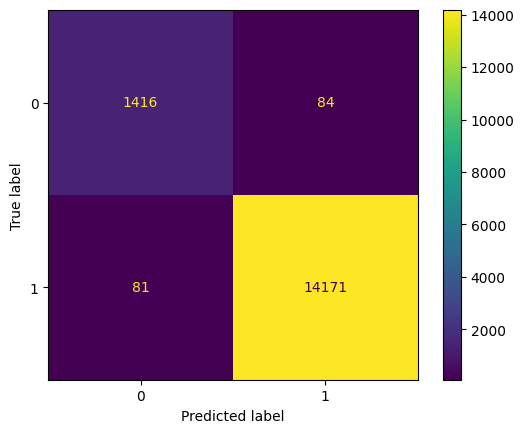

In [35]:
# display the confusion matrix
ConfusionMatrixDisplay.from_estimator(pcp, X_test, y_test)

## Logistic Regression Results

In [36]:
# compute the accuracy, display the computed measure
lrg_acc = accuracy_score(y_test, lrg_preds)
print('Logistic regression classifier accuracy: {:.4f}'.format(lrg_acc))

# compute the F1-score, display the computed measure
lrg_F1 = f1_score(y_test, lrg_preds)
print('Logistic regression classifier F1-score: {:.4f}'.format(lrg_F1))

# compute the precision, display the computed measure
lrg_pcn = precision_score(y_test, lrg_preds)
print('Logistic regression classifier precision: {:.4f}'.format(lrg_pcn))

# compute the recall, display the computed measure
lrg_rcl = recall_score(y_test, lrg_preds)
print('Logistic regression classifier recall: {:.4f}'.format(lrg_rcl))

Logistic regression classifier accuracy: 0.9942
Logistic regression classifier F1-score: 0.9968
Logistic regression classifier precision: 0.9939
Logistic regression classifier recall: 0.9997


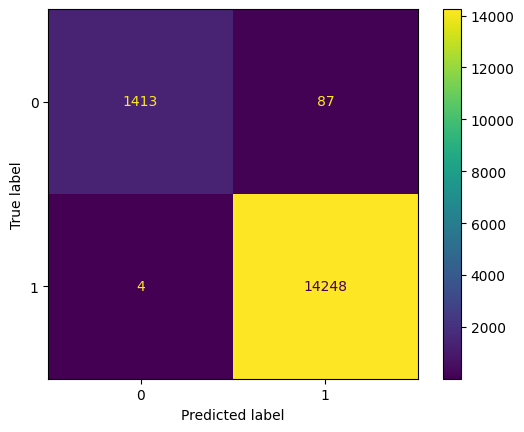

In [37]:
# display the confusion matrix
ConfusionMatrixDisplay.from_estimator(lrg, X_test, y_test)

## XGBoost Results

In [38]:
# compute the accuracy, display the computed measure
xgb_acc = accuracy_score(y_test, xgb_preds)
print('XGBoost classifier accuracy: {:.4f}'.format(xgb_acc))

# compute the F1-score, display the computed measure
xgb_F1 = f1_score(y_test, xgb_preds)
print('XGBoost classifier F1-score: {:.4f}'.format(xgb_F1))

# compute the precision, display the computed measure
xgb_pcn = precision_score(y_test, xgb_preds)
print('XGBoost classifier precision: {:.4f}'.format(xgb_pcn))

# compute the recall, display the computed measure
xgb_rcl = recall_score(y_test, xgb_preds)
print('XGBoost classifier recall: {:.4f}'.format(xgb_rcl))

XGBoost classifier accuracy: 0.9995
XGBoost classifier F1-score: 0.9997
XGBoost classifier precision: 0.9994
XGBoost classifier recall: 1.0000


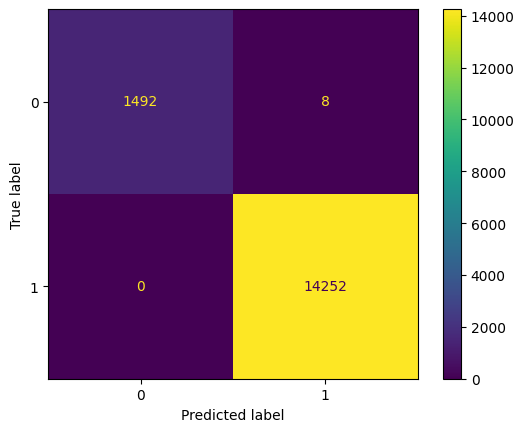

In [50]:
# display the confusion matrix
ConfusionMatrixDisplay.from_estimator(xgb, X_test, y_test)

## Decision Tree Results

In [41]:
# Compute the accuracy, display the computed measure
dt_acc = accuracy_score(y_test, dt_preds)
print('Decision Tree classifier accuracy: {:.4f}'.format(dt_acc))

# Compute the F1-score, display the computed measure
dt_F1 = f1_score(y_test, dt_preds)
print('Decision Tree classifier F1-score: {:.4f}'.format(dt_F1))

# Compute the precision, display the computed measure
dt_pcn = precision_score(y_test, dt_preds)
print('Decision Tree classifier precision: {:.4f}'.format(dt_pcn))

# Compute the recall, display the computed measure
dt_rcl = recall_score(y_test, dt_preds)
print('Decision Tree classifier recall: {:.4f}'.format(dt_rcl))

Decision Tree classifier accuracy: 0.9986
Decision Tree classifier F1-score: 0.9992
Decision Tree classifier precision: 0.9987
Decision Tree classifier recall: 0.9997


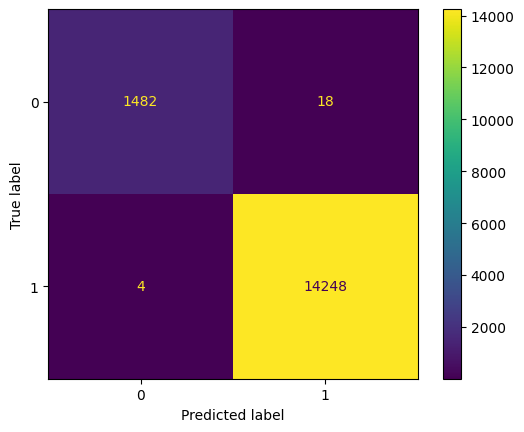

In [42]:
# Display the confusion matrix
ConfusionMatrixDisplay.from_estimator(dt, X_test, y_test)

## Random Forest Results

In [44]:
# Compute accuracy, display the computed measure
rf_acc = accuracy_score(y_test, rf_preds)
print('Random Forest classifier accuracy: {:.4f}'.format(rf_acc))

# Compute the F1-score, display the computed measure
rf_F1 = f1_score(y_test, rf_preds)
print('Random Forest classifier F1-score: {:.4f}'.format(rf_F1))

# Compute the precision, display the computed measure
rf_pcn = precision_score(y_test, rf_preds)
print('Random Forest classifier precision: {:.4f}'.format(rf_pcn))

# Compute the recall, display the computed measure
rf_rcl = recall_score(y_test, rf_preds)
print('Random Forest classifier recall: {:.4f}'.format(rf_rcl))

Random Forest classifier accuracy: 0.9992
Random Forest classifier F1-score: 0.9995
Random Forest classifier precision: 0.9992
Random Forest classifier recall: 0.9999


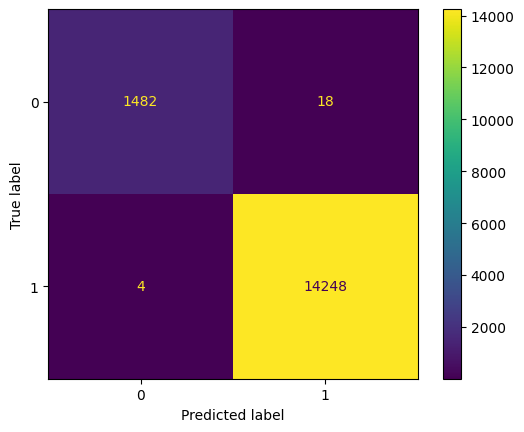

In [45]:
# Display the confusion matrix
ConfusionMatrixDisplay.from_estimator(dt, X_test, y_test)